# Adaptive memory testing analysis

This notebook reads `../simulated_data.zip` directly and summarizes adaptive trial metadata from the PsyNet export.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import json
import pandas as pd

zip_path = Path('../simulated_data.zip')
with ZipFile(zip_path) as zf:
    with zf.open('simulated_data/regular/data/MemoryTrial.csv') as f:
        trials = pd.read_csv(f)
    with zf.open('simulated_data/regular/data/Bot.csv') as f:
        bots = pd.read_csv(f)

trials = trials.sort_values(['participant_id', 'id']).copy()
trials['trial_index'] = trials.groupby('participant_id').cumcount() + 1
for column in ['posterior_summary', 'acquisition_values', 'model']:
    trials[column] = trials[column].apply(json.loads)
for name in ['mu_mean', 'alpha_mean', 'r_mean', 'mu_sd', 'alpha_sd', 'r_sd']:
    trials[name] = trials['posterior_summary'].apply(lambda value: value[name])
trials['correct'] = trials['score'].astype(int)
bots = bots[['id', 'memory_ability']].rename(columns={'id': 'participant_id'})
trials = trials.merge(bots, on='participant_id', how='left')
trials.shape

(60, 61)

In [2]:
overall

                             metric                   value
                       participants                       6
                             trials                      60
         unique synthetic abilities 0.45, 0.7, 1, 1.4, 2, 3
                min selected length                       2
                max selected length                      20
                   mean correctness                   0.367
metadata rows with joint parameters                      60

In [3]:
participant_summary

 participant_id  memory_ability  mean_length  final_length  accuracy  final_r_mean
              1            0.45          8.1            10       0.3         0.895
              2            0.70          8.1            12       0.4         1.101
              3            1.00         13.3            14       0.3         1.258
              4            1.40         10.1            11       0.3         1.050
              5            2.00          9.1            11       0.4         0.978
              6            3.00          9.8            15       0.5         1.330

In [4]:
trial_summary

 trial_index  mean_length  mean_accuracy  mean_r
           1        6.000          0.167   0.770
           2        5.667          0.667   0.658
           3        7.500          0.500   0.873
           4        9.500          0.667   0.979
           5       11.667          0.000   1.199
           6       10.667          0.167   1.045
           7       10.333          0.667   0.990
           8       12.000          0.167   1.135
           9       12.000          0.333   1.105
          10       12.167          0.333   1.102

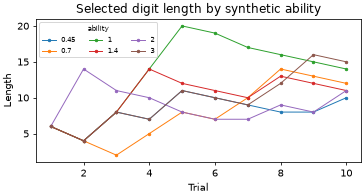

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5.2, 2.8), constrained_layout=True)
for ability, group in trials.sort_values(['memory_ability', 'trial_index']).groupby('memory_ability'):
    by_trial = group.groupby('trial_index').mean(numeric_only=True)
    ax.plot(by_trial.index, by_trial['length'], marker='o', linewidth=1, markersize=2.5, label=f'{ability:g}')
ax.set(title='Selected digit length by synthetic ability', xlabel='Trial', ylabel='Length', ylim=(1, 21))
ax.legend(title='ability', ncol=3, fontsize=7, title_fontsize=7);

## Interpretation

The simulated export contains 60 trials from 6 bots with abilities [0.45, 0.7, 1.0, 1.4, 2.0, 3.0]. All 60 trial metadata rows record joint updates for mu, alpha, and r_i. The lowest-ability bot trends toward short strings, while higher-ability bots receive longer strings.